In [17]:
import os
import sys

# Add the '../sources' directory to the Python path using source_dir,
# and add its parent directory as well.
source_dir = os.path.abspath(os.path.join("..", "sources"))
parent_dir = os.path.abspath(os.path.join(source_dir, os.pardir))

for directory in [source_dir, parent_dir]:
    if directory not in sys.path:
        sys.path.insert(0, directory)

print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")

Included '/zhome/2f/7/202918/phc_nzi/sources' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.


In [18]:
import numpy as np
T_array = np.linspace(4, 300, 5, endpoint=True)

def n_by_T(T):
    n = 3.075*(1+2.7e-5*T)
    return n

n_array = n_by_T(T_array)  
print(T_array)
print(n_array) 

[  4.  78. 152. 226. 300.]
[3.0753321  3.08147595 3.0876198  3.09376365 3.0999075 ]


In [ ]:
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import MPBSchemeConfigurator
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *

i = 4
n_InP = n_array[i]

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "mpi_T_" + f"{T_array[i]:.0f}"
print(name) 

## Define the lattice

lattice = Lattice(type="TXY")
centers = lattice.get_centers()
k_points = lattice.get_get_k_points_around_Gamma(distance = 0.5)

## Define the geometry

radius1 = Geometry.make_script_param(r1=0.2)
radius2 = Geometry.make_script_param(r2=0.3)
bulk = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": InP})
hole1 = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": 1e20, "material": air})
hole2 = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": 1e20, "material": air})
photonic_crystal = PhotonicCrystal(atoms=[bulk, hole1, hole2], lattice=lattice)

## Define the simulation

configuration_options_opt = dict(
    resolution=32,
    num_bands=8,
    k_points=[mp.Vector3(0, 0, 0)],
    k_point_interpolation_factor=None, 
)
mpb_config_opt = MPBSchemeConfigurator(photonic_crystal, ["te", "tm"], **configuration_options_opt)
script_opt = mpb_config_opt.get_scheme_config(join_newline=True)

configuration_options_single = dict(
    resolution=64,
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=20, 
)

mpb_config_single = MPBSchemeConfigurator(photonic_crystal, ["te", "tm"], **configuration_options_single)
script_single = mpb_config_single.get_scheme_config(join_newline=True)


Epsilon of InP:  9.61
mpi_T_300


In [31]:
# Instantiate the MPI optimization wrapper.
from sources.mpi_differential_evolution import MPIDiffEvoSimulation 
np = 32
pop = np//2
simulation_name_opt = name 
optimizer = MPIDiffEvoSimulation(simulation_name = simulation_name_opt, scheme_script= script_opt, maxiter=15,  param_names=["r1", "r2"], param_bounds=[(0.05, 0.15), (0.2, 0.4)], polarization="tm", de_options={"strategy": "rand1bin", "popsize": pop})
# Submit the LSF job.
submission_info = optimizer.submit_lsf_job(nprocs=np, walltime="00:30", queue="fotonano", span_option="block", span_value=8)
print("Submission info:", submission_info)

LSF job script written to: /tmp/tmpjmd98jjo.sh
Job submitted successfully. Submission output:
Job <24153210> is submitted to queue <fotonano>.

Waiting for job 24153210 to finish...


Waiting for LSF job: 380sec [06:26,  1.02s/sec, Job status: RUN, Elapsed: 382 sec]


KeyboardInterrupt: 

Log file path: mpi_T_300/mpi_T_300.log
DEBUG: Skipping line (expected 2 parameters, got 0): 1


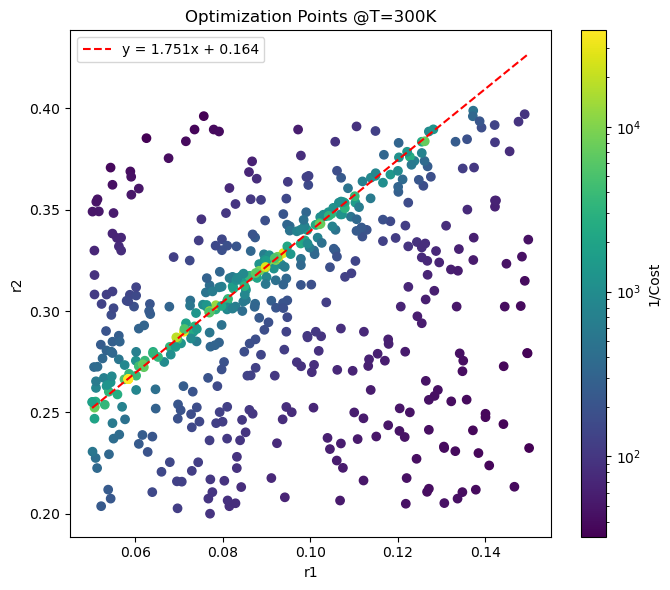

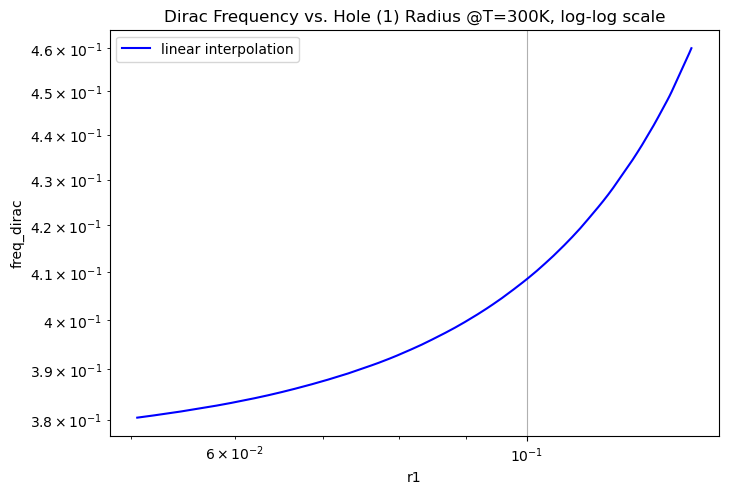

In [32]:
from sources.optimization_data_analyzer import OptimizationDataAnalyzer 
log_file = optimizer.log_file
print("Log file path:", log_file)  
analyzer = OptimizationDataAnalyzer(log_file)

# Load all data
analyzer.load_data(debug=True)

# Plot raw data as a scatter with 1/cost
analyzer.plot_raw_data(
    use_logscale=True,
    levels=100,
    points_only=True,
    plot_inverse_cost=True,
    custom_title=f"Optimization Points @T={T_array[i]:.0f}K"
)

# Overlay the fitted line on the scatter plot
analyzer.plot_fitted_line()
import matplotlib.pyplot as plt
plt.savefig(f"mpi_optimization_T_{T_array[i]:.0f}.png")

# Now compute freq_dirac along the fitted line
# and plot freq_dirac vs. param1.
analyzer.plot_freq_dirac_vs_param1_along_fit(
    n_points=200,
    interp_method='linear',
    custom_title=f"Dirac Frequency vs. Hole (1) Radius @T={T_array[i]:.0f}K"
)
plt.savefig(f"mpi_dirac_freq_vs_param1_T_{T_array[i]:.0f}.png")

ax = plt.gca()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Dirac Frequency vs. Hole (1) Radius @T={T_array[i]:.0f}K, log-log scale")    
plt.savefig(f"mpi_dirac_freq_vs_param1_T_{T_array[i]:.0f}_axislog.png")
